# Headline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download

In [ ]:
!pip install -U vnstock

## Import

In [ ]:
import numpy as np
import pandas as pd
from vnstock import *
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, bds
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.ar_model import AutoReg # Added this line
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tools.sm_exceptions import InterpolationWarning
from abc import ABC, abstractmethod
from sklearn.feature_selection import mutual_info_classif
from sklearn.mixture import GaussianMixture
from scipy.stats import entropy
from statsmodels.tsa.stattools import grangercausalitytests

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data Input

In [ ]:
# 1. Khởi tạo đối tượng Quote với mã DIG
# Nguồn hỗ trợ dữ liệu intraday/lịch sử phổ biến: 'VCI', 'KBS', 'TCBS'
symbol = 'DIG'
quote = Quote(symbol=symbol, source='KBS')

# 2. Tải dữ liệu lịch sử giá (khung 15 phút)
# Hoặc có thể truyền tham số tương đối: length='90D' thay cho start/end
df_raw = quote.history(
    start='2000-01-01',
    end='2026-06-01',
    interval='1D'
)

# 3. Chuẩn hóa tên cột & Index khớp với Pipeline sinh Features
# Dữ liệu trả về từ Vnstock 4.x thường gồm các cột chữ thường: 'time', 'open', 'high', 'low', 'close', 'volume'

# Lấy 500 nến gần nhất (tương đương n_bars = 500)
df_raw.to_csv('df_raw.csv', index=False)
display(df_raw.head())
display(df_raw.tail())

2026-08-31 07:57:31 - vnai.beam.patching - WARNING - ⚠️ Phiên bản cộng đồng: Dữ liệu OHLCV (1D) giới hạn tối đa 8 năm. Nâng cấp gói tài trợ để mở rộng giới hạn cho phân tích chuyên nghiệp: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program


,time,open,high,low,close,volume
0,2018-06-04 07:00:00,9.00,9.56,9.00,9.37,1439470
1,2018-06-05 07:00:00,9.23,9.65,9.23,9.65,1452440
2,2018-06-06 07:00:00,9.70,9.90,9.46,9.83,1273280
3,2018-06-07 07:00:00,9.70,9.79,9.46,9.51,1276620
4,2018-06-08 07:00:00,9.51,9.51,9.30,9.37,675770


,time,open,high,low,close,volume
1991,2026-05-26 07:00:00,13.70,14.15,13.65,13.80,7859600
1992,2026-05-27 07:00:00,13.85,13.90,13.75,13.75,3128400
1993,2026-05-28 07:00:00,13.80,13.85,13.50,13.50,4324500
1994,2026-05-29 07:00:00,13.45,13.55,13.05,13.05,5852300
1995,2026-06-01 07:00:00,13.25,13.40,13.10,13.20,5152700


In [ ]:
print(f"No. NaN values: {df_raw.isna().sum().sum()}")
display(df_raw.isna().sum()[df_raw.isna().sum() > 0])

No. NaN values: 0


,0


# Feature Engineering

## BƯỚC 1: XÁC LẬP BÀI TOÁN, KIỂM TOÁN VẬT LÝ VÀ CHUẨN HÓA TOPOLOGY DỮ LIỆU
Mục tiêu: Đảm bảo dữ liệu thô sạch hoàn toàn về mặt vật lý, xác lập không gian xác suất và tập thông tin $\mathcal{I}_t$.

In [ ]:
class Layer1DataIntegrity:
    @staticmethod
    def run_audit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        df = df.copy()
        initial_len = len(df)

        # 1. Deduplication & Chronological Sort
        if df.index.duplicated().any():
            df = df[~df.index.duplicated(keep='last')]
        df = df.sort_index()

        # 2. Geometric bounds audit
        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        # =================================================================
        # [FIX 1: LEAKAGE] SỬ DỤNG FORWARD-ADJUSTMENT THAY VÌ BACKWARD
        # Tránh việc quá khứ bị thay đổi bởi tương lai (Corporate actions).
        # =================================================================
        if 'split_factor' not in df.columns:
            df['split_factor'] = 1.0
        if 'dividend' not in df.columns:
            df['dividend'] = 0.0

        # Tính Daily Return thực tế bao gồm cổ tức và chia tách
        daily_ret = ((df['close'] + df['dividend']) / (df['close'].shift(1) * df['split_factor'])) - 1.0

        # Forward-adjusted price: Cố định giá ở quá khứ, tịnh tiến lên hiện tại
        df['close_adj'] = df['close'].iloc[0] * (1.0 + daily_ret).cumprod()
        df['close_adj'] = df['close_adj'].fillna(df['close'])

        # Căn chỉnh OHLA theo tỷ lệ của close
        ratio = df['close_adj'] / df['close']
        for col in ['open', 'high', 'low']:
            df[f'{col}_adj'] = df[col] * ratio

        return df, {"initial_bars": initial_len, "clean_bars": len(df)}

class Layer2ReturnTopologies:
    @staticmethod
    def compute(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])
        return df


class Layer0TripleBarrier:
    @staticmethod
    def label(df: pd.DataFrame, h: int = 2, pt: float = 1.0, sl: float = 1.0, vol_span: int = 3) -> pd.DataFrame:
        """
        Lưu ý: vol_span và h được cấu hình nhỏ (h=2, vol_span=3) để chạy demo trên tập 5 nến.
        Trên dataset thực tế dùng: h=5, vol_span=20.
        """
        df = df.copy()
        log_ret = df['log_return']
        sigma = log_ret.ewm(span=vol_span, min_periods=2).std().bfill()

        prices = df['close_adj'].values
        sigmas = sigma.values
        n = len(df)

        target = np.full(n, np.nan)
        ret_barrier = np.full(n, np.nan)
        touch_time = np.full(n, np.nan, dtype=object)

        for i in range(n - h):
            p0 = prices[i]
            upper_barrier = p0 * (1.0 + pt * sigmas[i])
            lower_barrier = p0 * (1.0 - sl * sigmas[i])

            window_prices = prices[i + 1 : i + h + 1]
            hit_upper = np.where(window_prices >= upper_barrier)[0]
            hit_lower = np.where(window_prices <= lower_barrier)[0]

            first_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
            first_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf

            if first_upper < first_lower and first_upper < np.inf:
                target[i] = 1.0
                ret_barrier[i] = (window_prices[first_upper] / p0) - 1.0
                touch_time[i] = df.index[i + 1 + first_upper]
            elif first_lower < first_upper and first_lower < np.inf:
                target[i] = -1.0
                ret_barrier[i] = (window_prices[first_lower] / p0) - 1.0
                touch_time[i] = df.index[i + 1 + first_lower]
            else:
                target[i] = 0.0
                ret_barrier[i] = (window_prices[-1] / p0) - 1.0
                touch_time[i] = df.index[i + h]

        df['local_volatility'] = sigma
        df['target_label'] = target
        df['target_barrier_return'] = ret_barrier
        df['barrier_touch_time'] = touch_time
        return df

## BƯỚC 2: CHẨN ĐOÁN TOÀN DIỆN ĐẶC TÍNH QUÁ TRÌNH SINH DỮ LIỆU (DGP DIAGNOSTICS)
Mục tiêu: Sử dụng các kiểm định thống kê và kinh tế lượng vi cấu trúc trên mảng dữ liệu đầu vào (chưa dùng target) để thu thập bằng chứng thực nghiệm.

In [ ]:
# =====================================================================
# CÁC LỚP CHẨN ĐOÁN HIỆN TẠI (Giữ nguyên)
# =====================================================================
class Layer3DistributionalDiagnostics:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        skew = float(stats.skew(r, bias=False))
        kurt = float(stats.kurtosis(r, fisher=False, bias=False))
        jb_stat, jb_p = stats.jarque_bera(r)

        return {
            "mean": float(np.mean(r)),
            "std": float(np.std(r, ddof=1)),
            "skewness": skew,
            "kurtosis": kurt,
            "is_leptokurtic": bool(kurt > 3.0),
            "jarque_bera_stat": float(jb_stat),
            "jarque_bera_pvalue": float(jb_p),
            "reject_normality": bool(jb_p < 0.05)
        }

class Layer4MemoryDependence:
    @staticmethod
    def compute_hurst_dfa(series: pd.Series) -> float:
        s = series.dropna().values
        y = np.cumsum(s - np.mean(s))
        n = len(y)
        if n < 40:
            return 0.5

        scales = np.floor(np.logspace(np.log10(10), np.log10(n // 4), num=15)).astype(int)
        scales = np.unique(scales)
        fluctuations = []

        for s_len in scales:
            num_segments = n // s_len
            segment_fluct = []
            for i in range(num_segments):
                seg = y[i * s_len : (i + 1) * s_len]
                x = np.arange(s_len)
                poly = np.polyfit(x, seg, 1)
                trend = np.polyval(poly, x)
                segment_fluct.append(np.sqrt(np.mean((seg - trend) ** 2)))
            fluctuations.append(np.mean(segment_fluct))

        poly_hurst = np.polyfit(np.log(scales), np.log(fluctuations), 1)
        return float(poly_hurst[0])

    @staticmethod
    def lo_mackinlay_vr(prices: pd.Series, k: int) -> dict:
        p = np.log(prices.dropna().values)
        t = len(p)
        if t <= k + 2:
            return {"vr": 1.0, "z_stat": 0.0, "p_value": 1.0}

        r1 = p[1:] - p[:-1]
        mu = (p[-1] - p[0]) / (t - 1)
        var_1 = np.sum((r1 - mu) ** 2) / (t - 2)

        rk = p[k:] - p[:-k]
        m = k * (t - k) * (1 - (k / (t - 1)))
        var_k = np.sum((rk - k * mu) ** 2) / m
        vr = var_k / var_1

        delta = np.zeros(k - 1)
        denom = (np.sum((r1 - mu) ** 2)) ** 2
        for j in range(1, k):
            num = np.sum(((r1[j:] - mu) ** 2) * ((r1[:-j] - mu) ** 2))
            delta[j - 1] = ((2.0 * (k - j) / k) ** 2) * (num / denom)

        phi_k = np.sum(delta)
        z_star = (vr - 1.0) / np.sqrt(phi_k) if phi_k > 0 else 0.0
        p_val = 2.0 * (1.0 - stats.norm.cdf(abs(z_star)))

        return {"vr": float(vr), "z_stat": float(z_star), "p_value": float(p_val)}

    @classmethod
    def multi_scale_memory(cls, prices: pd.Series, returns: pd.Series) -> dict:
        r = returns.dropna()
        max_lag = 30
        acf_vals = acf(r, nlags=max_lag, fft=True)
        conf_interval = 1.96 / np.sqrt(len(r))
        sig_lags = [i for i, val in enumerate(acf_vals[1:], 1) if abs(val) > conf_interval]

        if not sig_lags:
            sig_lags = [1, 3, 5]

        vr_short = cls.lo_mackinlay_vr(prices, k=3)
        vr_long = cls.lo_mackinlay_vr(prices, k=20)

        return {
            "dynamic_lags": sorted(list(set(sig_lags[:5] + [1, 5, 20]))),
            "hurst": cls.compute_hurst_dfa(returns),
            "short_term_mean_reverting": bool(vr_short['vr'] < 1.0 and vr_short['p_value'] < 0.05),
            "long_term_trending": bool(vr_long['vr'] > 1.0 and vr_long['p_value'] < 0.05),
            "vr_short_stat": vr_short,
            "vr_long_stat": vr_long
        }

# =====================================================================
# BỔ SUNG: LAYER 4b - CHU KỲ CHI PHỐI (SPECTRAL CYCLE)
# =====================================================================
class Layer4bSpectralCycleDiagnostics:
    """Phát hiện bước sóng chu kỳ chi phối (Fast Fourier Transform)."""
    @staticmethod
    def run(prices: pd.Series) -> dict:
        p = prices.dropna().values
        n = len(p)
        if n < 40:
            return {"dominant_cycle_len": 10}

        # Demean & Detrend
        detrended = p - np.polyval(np.polyfit(np.arange(n), p, 1), np.arange(n))
        fft_vals = np.abs(rfft(detrended))
        freqs = rfftfreq(n, d=1.0)

        # Bỏ tần số 0 (DC component)
        fft_vals[0] = 0
        peak_idx = np.argmax(fft_vals)
        dominant_freq = freqs[peak_idx] if freqs[peak_idx] > 0 else 0.1
        dominant_cycle = int(np.clip(1.0 / dominant_freq, 3, 30))

        return {
            "dominant_cycle_len": dominant_cycle
        }

class Layer5FractionalIntegration:
    @staticmethod
    def get_weights(d: float, size: int, threshold: float = 1e-4) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (d - k + 1)
            if abs(w_k) < threshold:
                break
            w.append(w_k)
        return np.array(w[::-1])

    @classmethod
    def fractionally_diff(cls, series: pd.Series, d: float, threshold: float = 1e-4) -> pd.Series:
        weights = cls.get_weights(d, len(series), threshold)
        width = len(weights)
        vals = series.values
        res = [np.dot(weights, vals[i - width : i]) for i in range(width, len(vals))]
        return pd.Series(res, index=series.index[width:], name=f"frac_diff_{d:.2f}")

    @classmethod
    def find_optimal_d(cls, series: pd.Series, d_step: float = 0.05) -> dict:
        s = series.dropna()
        adf_raw_p = adfuller(s, autolag='AIC')[1]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=InterpolationWarning)
            kpss_stat, kpss_raw_p, _, _ = kpss(s, regression='c', nlags="auto")

        best_d = 1.0
        best_corr = 0.0

        for d in np.arange(0.0, 1.05, d_step):
            fd = cls.fractionally_diff(s, d)
            if len(fd) < 50:
                continue
            adf_p = adfuller(fd.dropna(), autolag='AIC')[1]
            if adf_p < 0.05:
                best_d = float(round(d, 2))
                aligned = pd.concat([s, fd], axis=1).dropna()
                best_corr = float(np.corrcoef(aligned.iloc[:, 0], aligned.iloc[:, 1])[0, 1])
                break

        return {
            "price_stationary": bool(adf_raw_p < 0.05 and kpss_raw_p > 0.05),
            "optimal_d": best_d,
            "memory_retention_corr": best_corr
        }

class Layer6VolatilityDynamics:
    @staticmethod
    def estimate(df: pd.DataFrame) -> dict:
        c, o = df['close_adj'], df['open_adj']
        ret = np.log(c / c.shift(1)).dropna()

        lm_stat, lm_p, _, _ = het_arch(ret, nlags=5)

        ret_lag = ret.shift(1).dropna()
        vol_proxy = (ret**2).iloc[1:]
        aligned_df = pd.concat([ret_lag, vol_proxy], axis=1).dropna()
        leverage_corr = aligned_df.iloc[:,0].corr(aligned_df.iloc[:,1])

        return {
            "arch_lm_stat": float(lm_stat),
            "arch_lm_pvalue": float(lm_p),
            "has_arch_effect": bool(lm_p < 0.05),
            "leverage_effect_corr": float(leverage_corr),
            "has_asymmetric_vol": bool(leverage_corr < -0.1)
        }

# =====================================================================
# BỔ SUNG: LAYER 6b - TÁCH BƯỚC NHẢY BIẾN ĐỘNG (VOLATILITY JUMPS)
# =====================================================================
class Layer6bVolatilityJumpDiagnostics:
    """Kiểm định tách biến động bước nhảy (Barndorff-Nielsen & Shephard Jump Test)."""
    @staticmethod
    def run(df: pd.DataFrame, window: int = 20) -> dict:
        r = df['log_return'].dropna()
        # Realized Volatility (RV) proxy
        rv = (r ** 2).rolling(window).sum()
        # Bipower Variation (BV) - khử bước nhảy
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(window).sum()

        # Tỷ lệ Jump component: J = max(RV - BV, 0) / RV
        jump_ratio = np.maximum(rv - bv, 0) / (rv + 1e-8)
        significant_jumps = (jump_ratio > 0.25).sum()

        return {
            "has_volatility_jumps": bool(significant_jumps > (len(r) * 0.05)),
            "mean_jump_ratio": float(jump_ratio.mean())
        }

class Layer7LiquidityMicrostructure:
    @staticmethod
    def estimate(df: pd.DataFrame) -> pd.DataFrame:
        h, l = df['high'], df['low']
        h_prev, l_prev = h.shift(1), l.shift(1)

        gamma = (np.log(h / l) ** 2) + (np.log(h_prev / l_prev) ** 2)
        h_2d = np.maximum(h, h_prev)
        l_2d = np.minimum(l, l_prev)
        beta = np.log(h_2d / l_2d) ** 2

        den = 3.0 - 2.0 * np.sqrt(2.0)
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / den - np.sqrt(gamma / den)
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
        cs_spread = spread.clip(lower=0.0)

        dollar_volume = df['close'] * df['volume']
        ret = np.log(df['close'] / df['close'].shift(1)).abs()
        amihud = ret / dollar_volume.replace(0, np.nan)

        return pd.DataFrame({
            'corwin_schultz_spread': cs_spread,
            'amihud_illiq': amihud
        }, index=df.index)

class Layer7bVolumeDiagnostics:
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        v = df['volume'].dropna()
        r_abs = np.log(df['close_adj'] / df['close_adj'].shift(1)).abs().dropna()

        aligned = pd.concat([v, r_abs], axis=1).dropna()
        if aligned.empty:
            return {"is_volume_significant": False, "vol_ret_corr": 0.0}

        corr, p_val = stats.spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])

        return {
            "vol_ret_corr": float(corr),
            "is_volume_significant": bool(p_val < 0.05 and corr > 0.1)
        }

class Layer8NonlinearDependence:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()

        ar_res = AutoReg(r.values, lags=1).fit()
        resid = ar_res.resid

        resid_std = (resid - np.nanmean(resid)) / (np.nanstd(resid) + 1e-8)

        bds_stat, p_val = bds(resid_std, max_dim=2, epsilon=None)

        x_lag = r.shift(1).dropna()
        y_curr = r.iloc[1:]
        mi = mutual_info_regression(x_lag.values.reshape(-1, 1), y_curr.values, random_state=42)[0]

        return {
            "bds_stat_dim2": float(bds_stat),
            "bds_pvalue_dim2": float(p_val),
            "is_nonlinear_dependent": bool(p_val < 0.05),
            "mutual_information_lag1": float(mi)
        }

# =====================================================================
# BỔ SUNG: LAYER 8b - ĐỘ PHỨC TẠP VÀ HỖN LOẠN (COMPLEXITY ENTROPY)
# =====================================================================
class Layer8bComplexityDiagnostics:
    """Chẩn đoán tính bất định đa quy mô (Permutation Entropy)."""
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna().values
        if len(r) < 30:
            return {"is_high_complexity": False}

        # Permutation Entropy (m=3, tau=1)
        m, tau = 3, 1
        n = len(r) - (m - 1) * tau
        patterns = np.array([r[i : i + m * tau : tau] for i in range(n)])
        ranks = np.argsort(patterns, axis=1)
        _, counts = np.unique(ranks, axis=0, return_counts=True)
        probs = counts / counts.sum()

        # [SỬA LỖI] Thay np.math.factorial thành math.factorial
        pe = -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(math.factorial(m))

        return {
            "permutation_entropy": float(pe),
            "is_high_complexity": bool(pe > 0.85)  # Cờ nhận diện pha nhiễu ngẫu nhiên cao
        }

class Layer9RegimeStability:
    @staticmethod
    def run(returns: pd.Series) -> pd.DataFrame:
        r = returns.dropna()
        r_numeric = pd.Series(r.values)
        try:
            model = MarkovRegression(r_numeric, k_regimes=2, trend='c', switching_variance=True)
            res = model.fit(disp=False)
            probs = res.filtered_marginal_probabilities
            probs.index = r.index
            probs.columns = ['prob_regime_low_vol', 'prob_regime_high_vol']
            return probs
        except Exception:
            rolling_std = r.rolling(20).std()
            p_high = (rolling_std > rolling_std.median()).astype(float)
            return pd.DataFrame({
                'prob_regime_low_vol': 1.0 - p_high,
                'prob_regime_high_vol': p_high
            }, index=r.index)

### Scanner

In [ ]:
class Stage2DGPScanner:
    """
    Lớp điều phối toàn bộ Stage 2: Thu thập chẩn đoán và đóng gói thành payload
    để gửi cho Stage 3 Router. (Đã tích hợp Chu kỳ, Bước nhảy và Hỗn loạn)
    """
    @staticmethod
    def execute(df: pd.DataFrame) -> dict:
        returns = np.log(df['close_adj'] / df['close_adj'].shift(1)).dropna()
        prices = df['close_adj'].dropna()

        mem_stats = Layer4MemoryDependence.multi_scale_memory(prices, returns)
        cycle_stats = Layer4bSpectralCycleDiagnostics.run(prices) # NEW
        frac_stats = Layer5FractionalIntegration.find_optimal_d(prices)
        vol_stats = Layer6VolatilityDynamics.estimate(df)
        jump_stats = Layer6bVolatilityJumpDiagnostics.run(df) # NEW
        volu_stats = Layer7bVolumeDiagnostics.run(df)
        nonlin_stats = Layer8NonlinearDependence.run(returns)
        complex_stats = Layer8bComplexityDiagnostics.run(returns) # NEW

        # Đóng gói Routing Payload
        routing_payload = {
            "dynamic_lags": mem_stats['dynamic_lags'],
            "optimal_d": frac_stats['optimal_d'],
            "dominant_cycle": cycle_stats['dominant_cycle_len'], # NEW
            "flags": {
                "has_long_trend": mem_stats['long_term_trending'],
                "has_short_reversion": mem_stats['short_term_mean_reverting'],
                "has_vol_clustering": vol_stats['has_arch_effect'],
                "has_asymmetric_vol": vol_stats['has_asymmetric_vol'],
                "is_volume_significant": volu_stats['is_volume_significant'],
                "is_nonlinear": nonlin_stats['is_nonlinear_dependent'],
                "has_vol_jumps": jump_stats['has_volatility_jumps'], # NEW
                "is_high_complexity": complex_stats['is_high_complexity'] # NEW
            }
        }

        return routing_payload

## BƯỚC 3: QUYẾT ĐỊNH HỌ ĐẶC TRƯNG VÀ THIẾT KẾ KHÔNG GIAN DỮ LIỆU ỨNG VIÊN
Mục tiêu: Dùng bảng quyết định logic (Evidence-based Matrix) để chỉ sinh các họ feature có căn cứ kinh tế lượng, sau đó tính toán theo quy tắc đa quy mô.

### Feature Engineering Functions

In [ ]:
# =====================================================================
# 1. BASE STRATEGY INTERFACE
# =====================================================================

class BaseFeatureStrategy(ABC):
    @abstractmethod
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        """Thực thi tính toán ma trận đặc trưng một cách nhân quả (causal)."""
        pass

# =====================================================================
# 2. FEATURE STRATEGY MODULES (EXISTING & REFINED)
# =====================================================================

class BaselineStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        feat['geo_body_ratio'] = (c - o) / candle_range
        feat['geo_upper_shadow'] = (h - np.maximum(o, c)) / candle_range
        feat['geo_lower_shadow'] = (np.minimum(o, c) - l) / candle_range
        feat['overnight_gap'] = (o / c.shift(1)) - 1.0

        log_v = np.log(v + eps)
        for k in self.lags:
            if k >= 3:
                roll_vol_mean = v.shift(1).rolling(k).mean()
                feat[f'rvol_{k}'] = v / (roll_vol_mean + eps)
                mu_lv = log_v.shift(1).rolling(k).mean()
                std_lv = log_v.shift(1).rolling(k).std(ddof=1)
                feat[f'vol_shock_{k}'] = (log_v - mu_lv) / (std_lv + eps)

        if isinstance(df.index, pd.DatetimeIndex):
            dow = df.index.dayofweek
            month = df.index.month
            feat['sin_dow'] = np.sin(2 * np.pi * dow / 5.0)
            feat['cos_dow'] = np.cos(2 * np.pi * dow / 5.0)
            feat['sin_month'] = np.sin(2 * np.pi * month / 12.0)
            feat['cos_month'] = np.cos(2 * np.pi * month / 12.0)

        return feat

class TrendMomentumStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        for k in self.lags:
            ret_k = np.log(p / p.shift(k))
            feat[f'ret_{k}'] = ret_k
            feat[f'tsmom_sign_{k}'] = np.sign(ret_k)
            if k >= 3:
                roll_max = p.shift(1).rolling(k).max()
                roll_min = p.shift(1).rolling(k).min()
                feat[f'breakout_ratio_{k}'] = (p - roll_max) / ((roll_max - roll_min) + eps)

        ema_12 = p.ewm(span=12, adjust=False).mean()
        ema_26 = p.ewm(span=26, adjust=False).mean()
        feat['macd_dist'] = (ema_12 / ema_26) - 1.0
        feat['macd_slope_5'] = feat['macd_dist'] - feat['macd_dist'].shift(5)
        return feat

class OscillatorMeanReversionStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = [k for k in dynamic_lags if k <= 20] or [5, 10, 20]

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        for k in self.lags:
            if k >= 3:
                roll_mean = p.shift(1).rolling(k).mean()
                roll_std = p.shift(1).rolling(k).std(ddof=1)
                feat[f'zscore_{k}'] = (p - roll_mean) / (roll_std + eps)
                upper_band = roll_mean + (2.0 * roll_std)
                lower_band = roll_mean - (2.0 * roll_std)
                feat[f'bollinger_pctB_{k}'] = (p - lower_band) / ((upper_band - lower_band) + eps)

        delta = p.diff()
        gain = delta.where(delta > 0, 0.0).shift(1).rolling(14).mean()
        loss = -delta.where(delta < 0, 0.0).shift(1).rolling(14).mean()
        rs = gain / (loss + eps)
        feat['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))
        return feat

class FractionalMemoryStrategy(BaseFeatureStrategy):
    def __init__(self, optimal_d: float, threshold: float = 1e-4, max_window: int = 100):
        self.d = optimal_d
        self.threshold = threshold
        self.max_window = max_window
        self.weights_forward = self._compute_weights(max_window)
        self.actual_max_len = len(self.weights_forward)

    def _compute_weights(self, size: int) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (self.d - k + 1)
            if abs(w_k) < self.threshold:
                break
            w.append(w_k)
        return np.array(w)

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        def apply_frac_diff(x):
            x_rev = x[::-1]
            valid_len = min(len(x_rev), self.actual_max_len)
            return np.dot(self.weights_forward[:valid_len], x_rev[:valid_len])

        feat[f'frac_diff_d{self.d:.2f}'] = p.rolling(self.max_window, min_periods=10).apply(apply_frac_diff, raw=True)
        return feat

class VolatilityDynamicsStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int], has_asymmetric_vol: bool):
        self.lags = dynamic_lags
        self.has_asymmetric = has_asymmetric_vol

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        r = df['log_return']

        feat['vol_parkinson'] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * (np.log(h / l) ** 2))
        log_hl = np.log(h / l)
        log_co = np.log(c / o)
        gk_core = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
        feat['vol_garman_klass'] = np.sqrt(np.maximum(0.0, gk_core))
        rs_core = np.log(h / c) * np.log(h / o) + np.log(l / c) * np.log(l / o)
        feat['vol_rogers_satchell'] = np.sqrt(np.maximum(0.0, rs_core))

        window = 20
        o_prev_c = np.log(o / c.shift(1))
        c_prev_o = np.log(c / o)
        var_o = o_prev_c.rolling(window).var()
        var_c = c_prev_o.rolling(window).var()
        var_rs = pd.Series(rs_core, index=df.index).rolling(window).mean()
        k_val = 0.34 / (1.34 + (window + 1.0) / (window - 1.0))
        feat['vol_yang_zhang'] = np.sqrt(np.maximum(0.0, var_o + k_val * var_c + (1.0 - k_val) * var_rs))

        if self.has_asymmetric:
            downside_ret = r.where(r < 0, 0.0)
            feat['vol_downside_dev_20'] = downside_ret.rolling(20).std(ddof=1)
            feat['vol_upside_dev_20'] = r.where(r > 0, 0.0).rolling(20).std(ddof=1)
            feat['vol_semi_variance_ratio_raw'] = feat['vol_downside_dev_20'] / (feat['vol_upside_dev_20'] + eps)

        feat['skewness_20'] = r.rolling(20).skew()
        feat['kurtosis_20'] = r.rolling(20).kurt()

        return feat

class LiquidityMicrostructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high'], df['low'], df['close']
        v = df['volume']
        r = df['log_return']

        h_prev, l_prev = h.shift(1), l.shift(1)
        gamma = (np.log(h / l) ** 2) + (np.log(h_prev / l_prev) ** 2)
        h_2d = np.maximum(h, h_prev)
        l_2d = np.minimum(l, l_prev)
        beta = np.log(h_2d / l_2d) ** 2
        den = 3.0 - 2.0 * np.sqrt(2.0)
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / den - np.sqrt(gamma / den)
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
        feat['liq_spread_cs'] = spread.clip(lower=0.0)

        dollar_volume = c * v
        amihud_raw = r.abs() / dollar_volume.replace(0, np.nan)
        feat['liq_amihud_raw'] = amihud_raw
        roll_mean_illiq = amihud_raw.rolling(20).mean()
        roll_std_illiq = amihud_raw.rolling(20).std(ddof=1)
        feat['liq_amihud_z'] = (amihud_raw - roll_mean_illiq) / (roll_std_illiq + eps)

        def calc_autocorr_lag1(x):
            return pd.Series(x).autocorr(lag=1) if len(x) > 2 else 0.0

        feat['liq_roll_measure_20'] = r.rolling(20).apply(calc_autocorr_lag1, raw=False)
        feat['liq_log_turnover'] = np.log(dollar_volume + eps)
        feat['liq_turnover_ratio_20'] = dollar_volume / (dollar_volume.shift(1).rolling(20).mean() + eps)
        return feat

class NonlinearInteractionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']
        h, l = df['high_adj'], df['low_adj']

        feat['nonlin_ret_squared_signed'] = (r ** 2) * np.sign(r)
        feat['nonlin_ret_cubed'] = r ** 3
        daily_range = np.log(h / l)
        feat['nonlin_range_x_ret'] = daily_range * r
        feat['nonlin_ret_x_volshock'] = r * (df['volume'] / (df['volume'].shift(1).rolling(20).mean() + eps))
        return feat

class RegimeConditionedStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']

        roll_vol = r.rolling(20).std(ddof=1)
        vol_q50 = roll_vol.shift(1).rolling(60).median()
        p_high_vol = (roll_vol > vol_q50).astype(float)

        feat['regime_p_high_vol'] = p_high_vol
        feat['regime_weighted_return'] = r * p_high_vol
        feat['regime_transition_shock'] = p_high_vol.diff().abs()
        return feat

class KinematicDynamicsStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        h, l = df['high_adj'], df['low_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        feat['kinematic_velocity'] = r
        feat['kinematic_acceleration'] = r - r.shift(1)
        feat['kinematic_jerk'] = feat['kinematic_acceleration'] - feat['kinematic_acceleration'].shift(1)

        roll_mean = p.shift(1).rolling(20).mean()
        roll_std = p.shift(1).rolling(20).std(ddof=1)
        bb_width = 4.0 * roll_std

        tr1 = h - l
        tr2 = (h - p.shift(1)).abs()
        tr3 = (l - p.shift(1)).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.shift(1).rolling(20).mean()
        kc_width = 3.0 * atr

        feat['kinematic_squeeze_ratio'] = bb_width / (kc_width + eps)

        clv = ((p - l) - (h - p)) / (h - l + eps)
        feat['kinematic_clv_vol'] = clv * v
        feat['kinematic_clv_vol_roll20'] = feat['kinematic_clv_vol'].rolling(20).mean()
        return feat

class GMMRegimeStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 120, update_freq: int = 20):
        self.window = window
        self.update_freq = update_freq

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)
        vol = r.rolling(20).std(ddof=1).fillna(0)

        n = len(df)
        gmm_bull = np.zeros(n)
        gmm_bear = np.zeros(n)
        X = np.column_stack((r.values, vol.values))

        for i in range(self.window, n, self.update_freq):
            start_idx = max(0, i - self.window)
            X_train = np.nan_to_num(X[start_idx:i])
            pred_end = min(n, i + self.update_freq)
            X_test = np.nan_to_num(X[i:pred_end])

            try:
                if np.var(X_train[:, 0]) > 1e-8:
                    gmm = GaussianMixture(n_components=2, random_state=42, n_init=1)
                    gmm.fit(X_train)
                    probs = gmm.predict_proba(X_test)
                    means = gmm.means_
                    bull_idx = np.argmax(means[:, 0])
                    bear_idx = 1 - bull_idx
                    gmm_bull[i:pred_end] = probs[:, bull_idx]
                    gmm_bear[i:pred_end] = probs[:, bear_idx]
            except Exception:
                pass

        feat['gmm_prob_bull'] = gmm_bull
        feat['gmm_prob_bear'] = gmm_bear
        feat.iloc[:self.window, :] = np.nan
        return feat

class MarketEfficiencyStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        r = df['log_return'].fillna(0)

        vol_5 = r.rolling(5).std(ddof=1)
        vol_20 = r.rolling(20).std(ddof=1)
        feat['chaos_hurst_proxy'] = np.log(vol_20 / (vol_5 + eps)) / np.log(4.0)

        def calc_entropy(x):
            if len(x) < 10: return np.nan
            hist, _ = np.histogram(x, bins=10, density=True)
            p_data = hist[hist > 0]
            return entropy(p_data)

        feat['chaos_shannon_entropy_20'] = r.rolling(20).apply(calc_entropy, raw=True)
        net_change = p.diff(10).abs()
        sum_abs_change = p.diff().abs().rolling(10).sum()
        feat['chaos_kaufman_er_10'] = net_change / (sum_abs_change + eps)
        return feat

class OrderFlowToxicityStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        c, o, h, l = df['close_adj'], df['open_adj'], df['high_adj'], df['low_adj']
        v = df['volume']

        buy_pressure = (c - l) / (h - l + eps)
        sell_pressure = (h - c) / (h - l + eps)
        buy_vol = v * buy_pressure
        sell_vol = v * sell_pressure

        order_imbalance = buy_vol - sell_vol
        feat['flow_imbalance_raw'] = order_imbalance

        roll_mean_imb = order_imbalance.rolling(20).mean()
        roll_std_imb = order_imbalance.rolling(20).std(ddof=1)
        feat['flow_imbalance_zscore'] = (order_imbalance - roll_mean_imb) / (roll_std_imb + eps)

        vol_bucket = v.rolling(10).sum()
        imbalance_bucket = order_imbalance.abs().rolling(10).sum()
        feat['flow_vpin_proxy_10'] = imbalance_bucket / (vol_bucket + eps)
        return feat

# =====================================================================
# 3. ADVANCED INSTITUTIONAL MODULES
# =====================================================================

class AsymmetricStressStrategy(BaseFeatureStrategy):
    """Module Trạng thái Bất đối xứng và Áp lực Sụt giảm (Asymmetry & Drawdown)."""
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        # 1. Semi-Variance Decomposition & Asymmetry Ratio
        r_pos = np.maximum(r, 0)
        r_neg = np.minimum(r, 0)
        vol_up = r_pos.rolling(self.window).std(ddof=1)
        vol_down = r_neg.rolling(self.window).std(ddof=1)
        feat['asym_ratio_20'] = vol_up / (vol_down + eps)

        # 2. Cumulative Drawdown Indicator[cite: 1]
        synth_price = (1 + r).cumprod()
        rolling_max = synth_price.rolling(self.window).max()
        feat['drawdown_20'] = (synth_price - rolling_max) / (rolling_max + eps)

        # 3. Drawdown Velocity[cite: 1]
        feat['drawdown_velocity'] = feat['drawdown_20'] - feat['drawdown_20'].shift(1)
        return feat

class VolatilityTermStructureStrategy(BaseFeatureStrategy):
    """Module Cấu trúc Kỳ hạn & Gia tốc Biến động."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        # Volatility Term Structure Ratio (VTS)[cite: 1]
        vol_short = r.rolling(5).std(ddof=1)
        vol_long = r.rolling(20).std(ddof=1)
        feat['vts_5_20'] = vol_short / (vol_long + eps)

        # Volatility Acceleration[cite: 1]
        feat['vol_accel'] = feat['vts_5_20'] - feat['vts_5_20'].shift(1)
        return feat

class VWAPPressureStrategy(BaseFeatureStrategy):
    """Module Áp lực Dòng lệnh và Hồ sơ Khối lượng (Volume Profile)."""
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high_adj'], df['low_adj'], df['close_adj']
        v = df['volume']

        # Typical Price & Rolling VWAP[cite: 1]
        tp = (h + l + c) / 3.0
        tp_v = tp * v
        roll_tp_v = tp_v.rolling(self.window).sum()
        roll_v = v.rolling(self.window).sum()
        vwap = roll_tp_v / (roll_v + eps)

        # VWAP Distance[cite: 1]
        feat['vwap_distance_20'] = (c - vwap) / (vwap + eps)
        return feat

# =====================================================================
# BỔ SUNG: OHLCV ENDOGENOUS EXTENSIONS TỪ STAGE 2
# =====================================================================
class VolatilityJumpDiffusionStrategy(BaseFeatureStrategy):
    """Module Tách Biến động Bước nhảy (Jump vs Continuous Diffusion)."""
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        rv = (r ** 2).rolling(self.window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(self.window).sum()

        feat['jump_diffusion_component'] = np.maximum(rv - bv, 0.0) / (rv + eps)
        feat['continuous_vol_ratio'] = bv / (rv + eps)
        feat['jump_signed_shock'] = feat['jump_diffusion_component'] * np.sign(r)
        return feat

class MultiScaleComplexityStrategy(BaseFeatureStrategy):
    """Module Động lực học Phi tuyến & Entropy Đa quy mô."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        def calc_pe(x):
            if len(x) < 6: return np.nan
            m, tau = 3, 1
            n = len(x) - (m - 1) * tau
            patterns = np.array([x[i : i + m * tau : tau] for i in range(n)])
            ranks = np.argsort(patterns, axis=1)
            _, counts = np.unique(ranks, axis=0, return_counts=True)
            probs = counts / counts.sum()
            return -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(6.0)

        feat['chaos_permutation_entropy_20'] = r.rolling(20).apply(calc_pe, raw=True)

        binary_seq = (r > 0).astype(int)
        feat['lz_complexity_proxy_20'] = (binary_seq.diff().abs()).rolling(20).mean()
        return feat

class WaveletMultiResolutionStrategy(BaseFeatureStrategy):
    """Module Phân rã Đa phân giải Tần số (Haar Wavelet Approximation & Details)."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        feat['wavelet_detail_d1'] = (p - p.shift(1)) / np.sqrt(2.0)
        feat['wavelet_detail_d2'] = ((p + p.shift(1)) - (p.shift(2) + p.shift(3))) / 2.0
        feat['wavelet_approx_a3'] = p.rolling(8).mean()
        feat['wavelet_energy_ratio'] = (feat['wavelet_detail_d1'] ** 2) / ((feat['wavelet_detail_d2'] ** 2) + eps)
        return feat

class IntradayShadowPressureStrategy(BaseFeatureStrategy):
    """Module Cấu trúc Vi mô Nến & Bất cân xứng Cung - Cầu Nội phiên."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        body = (c - o).abs()
        upper_shadow = h - np.maximum(o, c)
        lower_shadow = np.minimum(o, c) - l

        feat['shadow_asymmetry_ratio'] = (upper_shadow - lower_shadow) / candle_range
        feat['buying_tail_power'] = (lower_shadow / candle_range) * v
        feat['selling_tail_power'] = (upper_shadow / candle_range) * v
        feat['body_efficiency_ratio'] = body / candle_range
        return feat

### Router Functions:

In [ ]:
# =====================================================================
# 4. ROUTER & PACKAGING (ĐÃ GẮN CỜ KIỂM SOÁT TỪ STAGE 2)
# =====================================================================
class Layer10FeatureRouter:
    """
    Bộ điều phối: Phân tích routing_payload từ Stage 2,
    cấp quyền và cấu hình siêu tham số động cho từng Feature Strategy.
    """
    def __init__(self, payload: dict):
        self.payload = payload
        self.registry: dict[str, BaseFeatureStrategy] = {}
        self._dispatch()

    def _dispatch(self):
        flags = self.payload.get('flags', {})
        lags = self.payload.get('dynamic_lags', [1, 3, 5, 10, 20])
        opt_d = self.payload.get('optimal_d', 1.0)
        dominant_cycle = self.payload.get('dominant_cycle', 10)

        # Các module luôn được khởi tạo (Base/Unconditional)
        self.registry["Baseline & Geometry"] = BaselineStrategy(dynamic_lags=lags)
        self.registry["Liquidity Microstructure"] = LiquidityMicrostructureStrategy()
        self.registry["Regime Dynamics"] = RegimeConditionedStrategy()
        self.registry["Kinematics & Flow"] = KinematicDynamicsStrategy()
        self.registry["GMM State Clustering"] = GMMRegimeStrategy(window=120, update_freq=20)
        self.registry["Chaos & Efficiency"] = MarketEfficiencyStrategy()
        self.registry["Intraday Shadow Pressure"] = IntradayShadowPressureStrategy()
        self.registry["Wavelet Multi-Resolution"] = WaveletMultiResolutionStrategy()

        # -------------------------------------------------------------
        # MODULES ĐƯỢC ĐIỀU PHỐI BỞI DGP DIAGNOSTICS (STAGE 2 FLAGS)
        # -------------------------------------------------------------

        if flags.get('has_long_trend', True):
            self.registry["Trend & Momentum"] = TrendMomentumStrategy(dynamic_lags=lags)

        if flags.get('has_short_reversion', True):
            self.registry["Oscillators & Reversion"] = OscillatorMeanReversionStrategy(dynamic_lags=lags)

        if 0.0 < opt_d < 1.0:
            self.registry["Fractional Memory"] = FractionalMemoryStrategy(optimal_d=opt_d)

        if flags.get('has_asymmetric_vol', False):
            self.registry["Asymmetric Stress"] = AsymmetricStressStrategy(window=20)

        if flags.get('has_vol_clustering', True):
            self.registry["Volatility Dynamics"] = VolatilityDynamicsStrategy(
                dynamic_lags=lags,
                has_asymmetric_vol=flags.get('has_asymmetric_vol', False)
            )
            self.registry["Volatility Term Structure"] = VolatilityTermStructureStrategy()

        if flags.get('is_volume_significant', True):
            self.registry["Order Flow Toxicity"] = OrderFlowToxicityStrategy()
            self.registry["VWAP Pressure"] = VWAPPressureStrategy(window=20)

        if flags.get('is_nonlinear', True):
            self.registry["Nonlinear Interactions"] = NonlinearInteractionStrategy()

        if flags.get('has_vol_jumps', False):
            self.registry["Volatility Jump Diffusion"] = VolatilityJumpDiffusionStrategy(window=20)

        if flags.get('is_high_complexity', False):
            self.registry["Multi-Scale Complexity"] = MultiScaleComplexityStrategy()

    def execute(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_frames = []
        for name, strategy in self.registry.items():
            mod_feat = strategy.construct(df)
            feature_frames.append(mod_feat)

        full_features = pd.concat(feature_frames, axis=1)
        return full_features

    def print_authorization_report(self):
        print("=" * 80)
        print("STAGE 3: ROUTER-DRIVEN FEATURE ENGINE AUTHORIZATION REPORT")
        print("=" * 80)
        for name, strategy in self.registry.items():
            strat_info = ""
            if isinstance(strategy, (BaselineStrategy, TrendMomentumStrategy)):
                strat_info = f"[Lags: {strategy.lags}]"
            elif isinstance(strategy, FractionalMemoryStrategy):
                strat_info = f"[Optimal d*: {strategy.d:.2f}]"
            elif isinstance(strategy, VolatilityDynamicsStrategy):
                strat_info = f"[Asymmetric Vol: {strategy.has_asymmetric}]"
            elif isinstance(strategy, GMMRegimeStrategy):
                strat_info = f"[Rolling Window: {strategy.window} days]"
            elif isinstance(strategy, VolatilityJumpDiffusionStrategy):
                strat_info = f"[Jump Window: {strategy.window} days]"
            print(f" ✓ {name:<30} {strat_info}")
        print("=" * 80)

## BƯỚC 4: KHỬ DƯ THỪA DỮ LIỆU VÀ ĐÁNH GIÁ SỨC MẠNH DỰ BÁO BIÊN
Mục tiêu: Nạp target $y_{t+h}$ vào để thanh lọc các biến cộng tuyến và đo lường lượng thông tin alpha thực chất.

In [ ]:
# =====================================================================
# LAYER 12: REDUNDANCY CONTROL (KHỬ DƯ THỪA)
# =====================================================================
class Layer12RedundancyControl:
    @staticmethod
    def linear_vif_prune(X: pd.DataFrame, threshold: float = 0.85, max_vif: float = 5.0) -> pd.DataFrame:
        """Nhánh Tuyến tính: Loại bỏ tương quan cặp và Đa cộng tuyến (VIF)."""
        X_curr = X.copy()

        # 1. Khử tương quan cặp
        corr_matrix = X_curr.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
        X_curr = X_curr.drop(columns=to_drop_corr)

        # 2. Khử VIF
        while True:
            if X_curr.shape[1] <= 1:
                break
            vifs = []
            cols = X_curr.columns
            X_vals = X_curr.values
            for j in range(len(cols)):
                y_target = X_vals[:, j]
                X_other = np.delete(X_vals, j, axis=1)
                X_mat = np.column_stack([np.ones(len(X_other)), X_other])

                try:
                    beta, _, _, _ = np.linalg.lstsq(X_mat, y_target, rcond=None)
                    preds = X_mat @ beta
                    ss_tot = np.sum((y_target - np.mean(y_target)) ** 2)
                    ss_res = np.sum((y_target - preds) ** 2)
                    r2 = 1.0 - (ss_res / (ss_tot + 1e-9))
                    vif = 1.0 / (1.0 - np.clip(r2, 0, 0.9999))
                except np.linalg.LinAlgError:
                    vif = max_vif + 1.0
                vifs.append(vif)

            max_vif_val = max(vifs)
            if max_vif_val > max_vif:
                drop_idx = np.argmax(vifs)
                X_curr = X_curr.drop(columns=[cols[drop_idx]])
            else:
                break
        return X_curr

    @staticmethod
    def nonlinear_hrp_prune(X: pd.DataFrame, max_clusters: int = 15) -> pd.DataFrame:
        """Nhánh Phi tuyến: Gom cụm HRP (Ward's linkage) để chọn Medoid."""
        if X.shape[1] <= max_clusters:
            return X

        corr = X.corr().clip(-1.0, 1.0).fillna(0)
        dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))

        dist_sym = (dist + dist.T) / 2.0
        np.fill_diagonal(dist_sym.values, 0)

        condensed_dist = squareform(dist_sym, checks=False)
        link = linkage(condensed_dist, method='ward')
        clusters = fcluster(link, t=max_clusters, criterion='maxclust')

        selected_medoids = []
        for c_id in np.unique(clusters):
            cluster_cols = X.columns[clusters == c_id]
            if len(cluster_cols) == 1:
                selected_medoids.append(cluster_cols[0])
            else:
                sub_dist = dist_sym.loc[cluster_cols, cluster_cols]
                medoid = sub_dist.sum(axis=1).idxmin()
                selected_medoids.append(medoid)

        return X[selected_medoids]

# =====================================================================
# LAYER 13: PREDICTIVE DIAGNOSTICS & GRANGER CAUSALITY
# =====================================================================
class Layer13PredictiveDiagnostics:
    @staticmethod
    def regime_conditioned_mi(X: pd.DataFrame, y: pd.Series, prob_high_vol: pd.Series, mi_thresh: float = 0.01) -> tuple:
        """Lọc Feature dựa trên Mutual Information (MI) phân rã theo trạng thái thị trường."""
        mask_high_vol = prob_high_vol > 0.5
        mask_low_vol = prob_high_vol <= 0.5

        mi_high = mutual_info_classif(X[mask_high_vol], y[mask_high_vol], random_state=42)
        mi_low = mutual_info_classif(X[mask_low_vol], y[mask_low_vol], random_state=42)
        mi_all = mutual_info_classif(X, y, random_state=42)

        valid_features = []
        results = []

        for idx, col in enumerate(X.columns):
            is_accepted = (mi_high[idx] > mi_thresh) or (mi_low[idx] > mi_thresh)
            if is_accepted:
                valid_features.append(col)

            results.append({
                'feature': col,
                'mi_high_vol': mi_high[idx],
                'mi_low_vol': mi_low[idx],
                'mi_all': mi_all[idx],
                'accepted': is_accepted
            })

        return pd.DataFrame(results).set_index('feature'), valid_features

    @staticmethod
    def granger_causality_screen(X: pd.DataFrame, y: pd.Series, max_lag: int = 5, p_threshold: float = 0.05) -> tuple:
        """
        Đánh giá tính nhân quả dự báo bằng kiểm định Granger[cite: 1].
        Chỉ giữ lại các tính năng thể hiện sự dẫn dắt thời gian đối với mục tiêu[cite: 1].
        """
        valid_features = []
        optimal_lags = {}

        df_test = pd.concat([y, X], axis=1).dropna()
        if df_test.empty:
            return valid_features, optimal_lags

        y_col = df_test.columns[0]

        for col in X.columns:
            test_data = df_test[[y_col, col]]
            try:
                gc_res = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                best_p = 1.0
                best_lag = 0

                # Tìm lag có F-statistic cao nhất (thể hiện qua p-value thấp nhất)[cite: 1]
                for lag in range(1, max_lag + 1):
                    p_val = gc_res[lag][0]['ssr_ftest'][1]
                    if p_val < best_p:
                        best_p = p_val
                        best_lag = lag

                if best_p < p_threshold:
                    valid_features.append(col)
                    optimal_lags[col] = best_lag

            except Exception:
                continue

        # Dự phòng: Nếu Granger loại bỏ quá mức, giữ lại 5 tính năng có tương quan cao nhất gán lag=1
        if len(valid_features) < 3:
            corr_with_y = df_test.drop(columns=[y_col]).corrwith(df_test[y_col]).abs()
            top_fallback = corr_with_y.sort_values(ascending=False).head(5).index.tolist()
            for f in top_fallback:
                if f not in valid_features:
                    valid_features.append(f)
                    optimal_lags[f] = 1

        return valid_features, optimal_lags

# =====================================================================
# LAYER 14: KINEMATIC & VOLATILITY-SCALED LAG TRANSFORM ENGINE
# =====================================================================
class Layer14LagTransformEngine:
    @staticmethod
    def apply_volatility_scaled_lags(X: pd.DataFrame, optimal_lags: dict, eps: float = 1e-8) -> pd.DataFrame:
        """
        Tạo tính năng dựa trên độ trễ tối ưu thông qua chuẩn hóa biến động và động lực học[cite: 1].
        """
        X_transformed = pd.DataFrame(index=X.index)

        for col, lag in optimal_lags.items():
            if col not in X.columns:
                continue
            feature_series = X[col]

            # 1. Volatility-Scaled Lag Features[cite: 1]
            roll_mean = feature_series.shift(lag).rolling(20).mean()
            roll_std = feature_series.shift(lag).rolling(20).std(ddof=1)

            z_scaled = (feature_series.shift(lag) - roll_mean) / (roll_std + eps)
            X_transformed[f'{col}_zscaled_lag{lag}'] = z_scaled

            # 2. Kinematic Transformations: First-order momentum[cite: 1]
            momentum = (feature_series - feature_series.shift(lag)) / (feature_series.shift(lag).abs() + eps)

            # 3. Kinematic Transformations: Second-order acceleration[cite: 1]
            acceleration = momentum - momentum.shift(1)

            X_transformed[f'{col}_momentum'] = momentum
            X_transformed[f'{col}_acceleration'] = acceleration

        return X_transformed

### Router Functions:

In [ ]:
# =====================================================================
# ROUTER CHÍNH CỦA STAGE 4 (Đã sửa lỗi đồng bộ tên biến Regime)
# =====================================================================
class Stage4SelectionRouter:
    """Pipeline điều phối đa tầng: Redundancy -> Causality -> Transformation -> Predictive Information."""
    def __init__(self, payload: dict):
        self.payload = payload
        self.max_clusters = payload.get('max_clusters', 15)
        self.mi_threshold = payload.get('mi_threshold', 0.01)

    def execute(self, X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
        aligned = pd.concat([X_train, y_train], axis=1).dropna()
        if aligned.empty:
            return X_train, {}

        X_mat = aligned.iloc[:, :-1]
        y_mat = aligned.iloc[:, -1]

        # PHASE 1: Khử dư thừa cấu trúc tuyến tính và phi tuyến
        print(f"  -> Lọc VIF (Đầu vào: {X_mat.shape[1]} features)...")
        X_pruned = Layer12RedundancyControl.linear_vif_prune(X_mat, threshold=0.85, max_vif=5.0)

        print(f"  -> Lọc HRP Clustering (Đầu vào: {X_pruned.shape[1]} features)...")
        X_hrp = Layer12RedundancyControl.nonlinear_hrp_prune(X_pruned, max_clusters=self.max_clusters)

        # Cứu lại cột trạng thái (regime) nếu nó bị HRP loại bỏ, phục vụ cho MI
        # [SỬA LỖI]: Đồng bộ tên cột thành 'regime_p_high_vol' từ Stage 3
        if 'regime_p_high_vol' in X_train.columns and 'regime_p_high_vol' not in X_hrp.columns:
            X_hrp['regime_p_high_vol'] = X_train['regime_p_high_vol']

        # PHASE 2: Sàng lọc nhân quả (Granger Causality)
        print(f"  -> Sàng lọc Granger Causality...")
        valid_granger_feats, optimal_lags = Layer13PredictiveDiagnostics.granger_causality_screen(X_hrp, y_mat)

        # PHASE 3: Biến đổi độ trễ theo biến động và động lượng
        print(f"  -> Biến đổi trễ & Động lực học (Lag Transformation)...")
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(X_hrp, optimal_lags)

        # Thêm lại Regime flag vào ma trận đã biến đổi để làm điều kiện cho MI
        # [SỬA LỖI]: Đồng bộ tên cột thành 'regime_p_high_vol'
        if 'regime_p_high_vol' in X_hrp.columns:
            X_transformed['regime_p_high_vol'] = X_hrp['regime_p_high_vol']

        # PHASE 4: Information Theory (Mutual Information)
        print(f"  -> Lọc Mutual Information (MI)...")
        valid_features = []
        X_transformed_clean = X_transformed.dropna()
        y_mat_clean = y_mat.loc[X_transformed_clean.index]

        # [SỬA LỖI]: Cập nhật logic trích xuất biến điều kiện MI
        if 'regime_p_high_vol' in X_transformed_clean.columns:
            prob_vol = X_transformed_clean['regime_p_high_vol']
            X_for_mi = X_transformed_clean.drop(columns=['regime_p_high_vol'])
            _, valid_features = Layer13PredictiveDiagnostics.regime_conditioned_mi(
                X=X_for_mi, y=y_mat_clean, prob_high_vol=prob_vol, mi_thresh=self.mi_threshold
            )
        else:
            mi_scores = mutual_info_classif(X_transformed_clean, y_mat_clean, random_state=42)
            for idx, col in enumerate(X_transformed_clean.columns):
                if mi_scores[idx] > self.mi_threshold:
                    valid_features.append(col)

        # Fallback an toàn cho MI
        if len(valid_features) < 3:
            print("  -> [Cảnh báo] Bộ lọc MI loại quá gắt, fallback chọn top 5 features.")
            X_for_mi = X_transformed_clean.drop(columns=['regime_p_high_vol'], errors='ignore')
            mi_scores_fallback = mutual_info_classif(X_for_mi, y_mat_clean, random_state=42)
            mi_series = pd.Series(mi_scores_fallback, index=X_for_mi.columns).sort_values(ascending=False)
            valid_features = mi_series.head(5).index.tolist()

        return X_transformed[valid_features], optimal_lags, valid_features

## Feature Engineering Packaging

In [ ]:
class Stage2DiagnosticEngine:
    """Đóng gói Stage 2: Chỉ chạy trên tập Train để trích xuất payload điều khiển."""
    def fit(self, df_train: pd.DataFrame) -> dict:
        returns = df_train['log_return'].dropna()
        prices = df_train['close_adj'].dropna()

        l3 = Layer3DistributionalDiagnostics.run(returns)
        l4 = Layer4MemoryDependence.multi_scale_memory(prices, returns)
        l4b = Layer4bSpectralCycleDiagnostics.run(prices)  # BỔ SUNG
        l5 = Layer5FractionalIntegration.find_optimal_d(prices)
        l6 = Layer6VolatilityDynamics.estimate(df_train)
        l6b = Layer6bVolatilityJumpDiagnostics.run(df_train)  # BỔ SUNG
        l7b = Layer7bVolumeDiagnostics.run(df_train)
        l8 = Layer8NonlinearDependence.run(returns)
        l8b = Layer8bComplexityDiagnostics.run(returns)  # BỔ SUNG

        return {
            "dynamic_lags": l4["dynamic_lags"],
            "optimal_d": l5["optimal_d"],
            "dominant_cycle": l4b["dominant_cycle_len"],  # BỔ SUNG
            "flags": {
                "is_fat_tail": l3["is_leptokurtic"],
                "has_short_reversion": l4["short_term_mean_reverting"],
                "has_long_trend": l4["long_term_trending"],
                "has_vol_clustering": l6["has_arch_effect"],
                "has_asymmetric_vol": l6["has_asymmetric_vol"],
                "is_volume_significant": l7b["is_volume_significant"],
                "is_nonlinear": l8["is_nonlinear_dependent"],
                "has_vol_jumps": l6b["has_volatility_jumps"],  # BỔ SUNG
                "is_high_complexity": l8b["is_high_complexity"]  # BỔ SUNG
            }
        }

class Stage3FeatureEngine:
    """Đóng gói Stage 3: Khởi tạo bằng Payload, transform trên mọi tập dữ liệu."""
    def __init__(self, payload: dict):
        self.router = Layer10FeatureRouter(payload)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df_features = self.router.execute(df)
        return df_features

class Stage4SelectionEngine:
    """Đóng gói Stage 4: Chọn lọc và Biến đổi tính năng dựa trên môi trường tập Train."""
    def __init__(self, payload: dict):
        self.payload = payload
        self.router = Stage4SelectionRouter(payload)
        self.optimal_lags_ = None
        self.selected_features_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        # Chạy toàn bộ luồng HRP -> Granger -> Lag Transform -> MI
        _, optimal_lags, final_features = self.router.execute(X_train, y_train)

        self.optimal_lags_ = optimal_lags
        self.selected_features_ = final_features
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.optimal_lags_ is None or self.selected_features_ is None:
            raise ValueError("Mô hình chưa được fit(). Vui lòng gọi fit() trên tập train trước.")

        # 1. Áp dụng Biến đổi độ trễ lên tập Test (với bộ lags học từ Train)
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(X, self.optimal_lags_)

        # 2. Cắt đúng các cột đã vượt qua bộ lọc MI
        available_cols = [c for c in self.selected_features_ if c in X_transformed.columns]
        return X_transformed[available_cols]

class EconometricsFeaturePipeline(BaseEstimator, TransformerMixin):
    """
    Pipeline đầu cuối, kết hợp tự động Stage 2, 3 và 4.
    Bảo vệ ranh giới thông tin (Time Barrier) giữa Train/Test[cite: 1].
    """
    def __init__(self, target_horizon: int = 5):
        self.target_horizon = target_horizon
        self.is_fitted = False
        self.s2_engine = None
        self.s3_engine = None
        self.s4_engine = None
        self.routing_payload_ = None
        self.final_features_list_ = None

    def _prepare_target(self, df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
        y = df['target_label'].copy().rename("target")
        valid_idx = y.dropna().index
        return df.loc[valid_idx], y.loc[valid_idx]

    def fit(self, X: pd.DataFrame, y=None):
        print(f"--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN ({X.index[0].date()} đến {X.index[-1].date()}) ---")

        # 1. Căn chỉnh Target
        X_data, y_data = self._prepare_target(X)
        aligned = pd.concat([X_data, y_data], axis=1).dropna()
        X_train_aligned = aligned.drop(columns=['target'])
        y_train_aligned = aligned['target']

        # 2. Fit Stage 2: Diagnostic
        self.s2_engine = Stage2DiagnosticEngine()
        self.routing_payload_ = self.s2_engine.fit(X_train_aligned)

        # 3. Transform Stage 3: Feature Construction
        self.s3_engine = Stage3FeatureEngine(self.routing_payload_)
        X_train_candidates = self.s3_engine.transform(X_train_aligned)

        aligned_s3 = pd.concat([X_train_candidates, y_train_aligned], axis=1).dropna()
        X_train_candidates = aligned_s3.drop(columns=['target'])
        y_train_candidates = aligned_s3['target']

        # 4. Fit Stage 4: Feature Selection & Lag Transform
        self.s4_engine = Stage4SelectionEngine(self.routing_payload_)
        self.s4_engine.fit(X_train_candidates, y_train_candidates)

        self.final_features_list_ = self.s4_engine.selected_features_
        self.is_fitted = True

        print("--- FIT PIPELINE HOÀN TẤT ---")
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Pipeline chưa được fit. Hãy gọi fit(df_train) trước.")

        # Sinh ứng viên tĩnh bằng Stage 3
        X_test_candidates = self.s3_engine.transform(X)

        # Biến đổi trễ động học và cắt tính năng bằng Stage 4
        X_test_final = self.s4_engine.transform(X_test_candidates)

        return X_test_final.dropna(thresh=len(X_test_final.columns) // 2)

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X, y).transform(X)

# Modeling

## Data Preprocessing

In [ ]:
df = pd.read_csv("/content/df_raw.csv")
# Convert the 'time' column to datetime objects and set it as the index
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

df_clean, audit_stats = Layer1DataIntegrity.run_audit(df)
df_topo = Layer2ReturnTopologies.compute(df_clean)
df_final = Layer0TripleBarrier.label(df_topo, h=5, pt=1.0, sl=1.0, vol_span=20)

# Xuất bảng Markdown các đặc trưng Topo & Target phục vụ bài viết
cols_for_paper = [
    'close_adj', 'log_return', 'overnight_return',
    'intraday_return', 'hl_log_range', 'local_volatility',
    'target_label', 'target_barrier_return'
]

print("=== EMPIRICAL AUDIT METRICS (LAYER 1) ===")
for k, v in audit_stats.items():
    print(f"- {k}: {v}")

print("\n=== PROCESSED DATASET (STAGE 1 OUTPUT TABLE) ===")
print(df_final[cols_for_paper].head().to_markdown(index=True))

df_final.to_csv("/content/df_final.csv")

=== EMPIRICAL AUDIT METRICS (LAYER 1) ===
- initial_bars: 1996
- clean_bars: 1996

=== PROCESSED DATASET (STAGE 1 OUTPUT TABLE) ===
| time                |   close_adj |   log_return |   overnight_return |   intraday_return |   hl_log_range |   local_volatility |   target_label |   target_barrier_return |
|:--------------------|------------:|-------------:|-------------------:|------------------:|---------------:|-------------------:|---------------:|------------------------:|
| 2018-06-04 07:00:00 |        9.37 |  nan         |       nan          |         0.0402885 |      0.0603631 |         0.00775258 |              1 |               0.0298826 |
| 2018-06-05 07:00:00 |        9.65 |    0.0294448 |        -0.015054   |         0.0444989 |      0.0444989 |         0.00775258 |              1 |               0.0186528 |
| 2018-06-06 07:00:00 |        9.83 |    0.018481  |         0.00516797 |         0.013313  |      0.0454624 |         0.00775258 |             -1 |              -0.032

## Model Testing

In [ ]:
class PurgedTimeSeriesSplit:
    """
    Kỹ thuật chia Walk-Forward có tích hợp Purging để chặn rò rỉ
    thông tin tương lai do nhãn dự báo (Target) chồng lấn.
    """
    def __init__(self, n_splits=5, purge_gap=5):
        self.n_splits = n_splits
        self.purge_gap = purge_gap

    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        base_splits = list(tscv.split(X))

        for train_idx, test_idx in base_splits:
            # Purge: Bỏ qua h điểm cuối của Train Set
            train_idx_purged = train_idx[train_idx < (test_idx[0] - self.purge_gap)]
            if len(train_idx_purged) > 0:
                yield train_idx_purged, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        """Hàm bắt buộc phải có để Scikit-learn nhận diện Cross Validator"""
        return self.n_splits

# =========================================================
# VÒNG LẶP MODELING KẾT HỢP HYPER-PARAMETER TUNING
# =========================================================
n_splits = 5
target_horizon = 5
buffer_days = 60

# Sử dụng Purged CV đã định nghĩa ở phần trước
ptscv = PurgedTimeSeriesSplit(n_splits=n_splits, purge_gap=target_horizon)

oos_predictions = []
trained_models = []

print("=" * 80)
print(f"BẮT ĐẦU END-TO-END PURGED WALK-FORWARD VALIDATION")
print("=" * 80)

# df_final ở đây chính là Bảng Data Raw từ Stage 1 Output
for fold, (train_idx, test_idx) in enumerate(ptscv.split(df_final)):
    print(f"\n[FOLD {fold + 1}/{n_splits}]")

    # 1. Tách Index cho Train và Test (Dữ liệu Raw)
    df_train_raw = df_final.iloc[train_idx].copy()
    df_test_raw = df_final.iloc[test_idx].copy()

    # Tạo Buffer cho Test Set để tránh NaN khi tính Rolling Features (như MA, Volatility)
    buffer_data = df_train_raw.iloc[-buffer_days:].copy()
    df_test_with_buffer = pd.concat([buffer_data, df_test_raw])

    # =================================================================
    # 2. FEATURE ENGINEERING (Chỉ Fit trên Train Set)
    # =================================================================
    print("  -> Chạy Feature Engineering Pipeline...")
    pipeline = EconometricsFeaturePipeline(target_horizon=target_horizon)
    pipeline.fit(df_train_raw)

    # Transform Train Set
    X_train_features = pipeline.transform(df_train_raw)
    _, y_train_target = pipeline._prepare_target(df_train_raw)

    # Căn chỉnh Train Set (Bỏ các dòng NaNs do rolling ở đầu và shift ở cuối)
    train_aligned = pd.concat([X_train_features, y_train_target], axis=1).dropna()
    X_train = train_aligned.drop(columns=['target'])
    y_train = train_aligned['target']

    # Transform Test Set (Sử dụng buffer để giữ nguyên các bar đầu tiên của test_idx)
    X_test_buffer = pipeline.transform(df_test_with_buffer)
    _, y_test_buffer = pipeline._prepare_target(df_test_with_buffer)

    # =================================================================
    # SỬ DỤNG INDEX ALIGNMENT CHO TẬP TEST
    # =================================================================
    start_time = df_test_raw.index[0]

    # Cắt X_test_features lấy từ thời điểm bắt đầu của tập Test
    X_test_features_raw = X_test_buffer.loc[X_test_buffer.index >= start_time]

    # Điểm giao thoa: Lọc bỏ những ngày khuyết target ở cuối
    common_index = X_test_features_raw.index.intersection(y_test_buffer.index)

    X_test_features = X_test_features_raw.loc[common_index]
    y_test_target = y_test_buffer.loc[common_index]

    # Căn chỉnh Test Set
    test_aligned = pd.concat([X_test_features, y_test_target], axis=1).dropna()
    if test_aligned.empty:
        print("  -> [Cảnh báo] Test set bị empty sau khi căn chỉnh. Bỏ qua fold này.")
        continue

    X_test = test_aligned.drop(columns=['target'])
    y_test = test_aligned['target']
    print(f"  -> Kích thước Train: {X_train.shape} | Test: {X_test.shape}")

    # =================================================================
    # 3. HYPER-PARAMETER TUNING & MODELING (XGBoost)
    # =================================================================
    print("  -> Đang Tuning Hyper-parameters...")

    # MAP NHÃN CHO XGBOOST (-1, 0, 1  -->  0, 1, 2)
    y_train_mapped = y_train + 1
    y_test_mapped = y_test + 1

    # Khởi tạo mô hình phân loại đa lớp
    base_model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        random_state=42,
        n_jobs=-1
    )

    param_dist = {
        'n_estimators': [50, 100, 150],
        'max_depth': [2, 3],
        'learning_rate': [0.01, 0.05],
        'subsample': [0.6, 0.8],
        'colsample_bytree': [0.6, 0.8],
        'reg_alpha': [0.1, 1.0, 5.0],
        'reg_lambda': [1.0, 5.0, 10.0]
    }

    inner_cv = PurgedTimeSeriesSplit(n_splits=3, purge_gap=target_horizon)

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=10,
        scoring='accuracy',
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train_mapped)
    best_model = random_search.best_estimator_

    print(f"  -> Best Params: depth={best_model.max_depth}, lr={best_model.learning_rate}")

    # =================================================================
    # 4. PROBABILITY THRESHOLDING & CONTRARIAN FLIP
    # =================================================================
    probs = best_model.predict_proba(X_test)

    prob_short = probs[:, 0]
    prob_neutral = probs[:, 1]
    prob_long = probs[:, 2]

    # [NÂNG CẤP] Ép ngưỡng tự tin lên 55% để lọc nhiễu vi mô và giảm Turnover
    CONFIDENCE_THRESHOLD = 0.55

    y_pred_real = np.zeros(len(X_test))
    y_pred_real[prob_long > CONFIDENCE_THRESHOLD] = 1
    y_pred_real[prob_short > CONFIDENCE_THRESHOLD] = -1

    y_test_real = y_test_mapped - 1

    # =================================================================
    # 5. ML DIAGNOSTICS (EVALUATION REPORT)
    # =================================================================
    acc = accuracy_score(y_test_real, y_pred_real)
    f1_macro = f1_score(y_test_real, y_pred_real, average='macro')

    print("-" * 60)
    print(f"  [ML DIAGNOSTICS - FOLD {fold+1} OOS]")
    print(f"  Accuracy : {acc:.4f} | Macro F1 : {f1_macro:.4f}")

    clf_report = classification_report(
        y_test_real,
        y_pred_real,
        labels=[-1, 0, 1],
        target_names=['Short (-1)', 'Neutral (0)', 'Long (1)'],
        zero_division=0
    )
    print(clf_report)
    print("-" * 60)

    # [NÂNG CẤP] Thực thi Đảo nghịch Tín hiệu (Contrarian Flip)
    y_pred_traded = -1 * y_pred_real

    fold_result_df = pd.DataFrame({
        'fold': fold + 1,
        'predicted_target': y_pred_traded,  # Tín hiệu ĐÃ ĐẢO CHIỀU đưa vào Backtest
        'model_raw_target': y_pred_real,    # Tín hiệu thuận chiều gốc của mô hình
        'actual_target': y_test_real,
        'prob_long': prob_long,
        'prob_short': prob_short
    }, index=y_test.index)

    oos_predictions.append(fold_result_df)
    trained_models.append(best_model)

full_oos_predictions = pd.concat(oos_predictions).sort_index()
print("\n" + "=" * 80)
print(f"HOÀN TẤT PREDICTION TRÊN {len(full_oos_predictions)} SAMPLES OOS")
print("=" * 80)

BẮT ĐẦU END-TO-END PURGED WALK-FORWARD VALIDATION

[FOLD 1/5]
  -> Chạy Feature Engineering Pipeline...
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (2018-06-04 đến 2019-09-26) ---
  -> Lọc VIF (Đầu vào: 71 features)...
  -> Lọc HRP Clustering (Đầu vào: 34 features)...
  -> Sàng lọc Granger Causality...
  -> Biến đổi trễ & Động lực học (Lag Transformation)...
  -> Lọc Mutual Information (MI)...
--- FIT PIPELINE HOÀN TẤT ---
  -> Kích thước Train: (308, 14) | Test: (332, 14)
  -> Đang Tuning Hyper-parameters...
  -> Best Params: depth=2, lr=0.05
------------------------------------------------------------
  [ML DIAGNOSTICS - FOLD 1 OOS]
  Accuracy : 0.2500 | Macro F1 : 0.2476
              precision    recall  f1-score   support

  Short (-1)       0.31      0.20      0.24       110
 Neutral (0)       0.17      0.73      0.27        51
    Long (1)       0.57      0.14      0.23       171

    accuracy                           0.25       332
   macro avg       0.35      0.36      0.25      

## Backtest: Realistic Execution Simulator

In [ ]:
class VectorizedBacktestSimulator:
    """
    Giả lập Backtest có tính đến độ trễ khớp lệnh và chi phí giao dịch.
    Chuyển đổi tín hiệu thành Position sizing và tính Net P&L.
    """
    def __init__(self, fee_bps: float = 15.0, slippage_bps: float = 5.0, execution_lag: int = 1):
        # Tổng chi phí 1 chiều giao dịch (Ví dụ: 20 bps = 0.2%)
        self.tc = (fee_bps + slippage_bps) / 10000.0
        self.lag = execution_lag

    def run(self, predictions: pd.Series, df_market: pd.DataFrame) -> dict:
        """
        predictions: Chuỗi dự báo OOS (Index là Datetime)
        df_market: Dataframe chứa dữ liệu thị trường thực tế ('log_return')
        """
        # Căn chỉnh dữ liệu
        aligned = pd.concat([predictions, df_market['log_return']], axis=1, join='inner').dropna()
        y_pred = aligned.iloc[:, 0]
        daily_return = aligned.iloc[:, 1] # Lợi nhuận sinh ra trong ngày t

        # 1. POSITION SIZING (Directional)
        # Tín hiệu được sinh ra ở cuối ngày t
        target_position = -1 * y_pred

        # 2. EXECUTION LAG
        # Do tín hiệu có ở cuối ngày t, vị thế thực tế chỉ bắt đầu có tác dụng từ ngày t+1
        actual_position = target_position.shift(self.lag).fillna(0)

        # 3. TURNOVER & TRANSACTION COSTS
        # Tính sự thay đổi vị thế (Turnover = |W_t - W_{t-1}|)
        position_change = actual_position.diff().fillna(0)
        turnover = position_change.abs()
        transaction_costs = turnover * self.tc

        # 4. MARK-TO-MARKET P&L
        # Lợi nhuận gộp = Vị thế giữ qua đêm x Lợi nhuận ngày hôm sau
        gross_strategy_return = actual_position * daily_return

        # Lợi nhuận ròng sau phí
        net_strategy_return = gross_strategy_return - transaction_costs

        # Tính Equity Curve (Lãi kép)
        equity_curve = np.exp(net_strategy_return.cumsum())

        # 5. RISK METRICS (Annualized)
        mean_ret = net_strategy_return.mean() * 252
        std_ret = net_strategy_return.std() * np.sqrt(252)
        net_sharpe = mean_ret / std_ret if std_ret > 0 else 0.0

        # Maximum Drawdown (MDD)
        roll_max = equity_curve.cummax()
        drawdown = (equity_curve - roll_max) / roll_max
        mdd = drawdown.min()

        # Rank IC (Đánh giá sức mạnh dự báo nguyên thủy)
        # Cần đối chiếu dự báo với lợi nhuận lũy kế 5 ngày thực tế để tính IC chính xác
        actual_h_day_ret = daily_return.rolling(5).sum().shift(-5).dropna()
        valid_idx = y_pred.index.intersection(actual_h_day_ret.index)
        ic, _ = stats.spearmanr(y_pred.loc[valid_idx], actual_h_day_ret.loc[valid_idx])

        return {
            'N_Trades': turnover.sum() / 2, # Chia 2 vì 1 trade gồm vào và ra
            'Rank_IC': ic,
            'Net_Annualized_Return': mean_ret,
            'Net_Sharpe': net_sharpe,
            'Max_Drawdown': mdd,
            'Calmar_Ratio': mean_ret / abs(mdd) if mdd < 0 else np.inf,
            'Total_Turnover': turnover.sum(),
            'Equity_Curve': equity_curve
        }

# =========================================================
# THỰC THI BACKTEST TRÊN TOÀN BỘ KẾT QUẢ OOS
# =========================================================
simulator = VectorizedBacktestSimulator(fee_bps=15, slippage_bps=5, execution_lag=1)

print("\n" + "=" * 80)
print("OUT-OF-SAMPLE BACKTEST REPORT (NET OF FEES)")
print("=" * 80)

metrics_list = []
for fd in sorted(full_oos_predictions['fold'].unique()):
    fold_preds = full_oos_predictions[full_oos_predictions['fold'] == fd]['predicted_target']
    metrics = simulator.run(fold_preds, df_final)
    metrics['Fold'] = f"Fold_{fd}"
    metrics_list.append(metrics)

# Đánh giá Overall (Gộp toàn bộ quá trình)
overall_metrics = simulator.run(full_oos_predictions['predicted_target'], df_final)
overall_metrics['Fold'] = "OVERALL"
metrics_list.append(overall_metrics)

report_df = pd.DataFrame(metrics_list).set_index('Fold')
report_df = report_df.drop(columns=['Equity_Curve'])

print(report_df.round(4).to_string())


OUT-OF-SAMPLE BACKTEST REPORT (NET OF FEES)
         N_Trades  Rank_IC  Net_Annualized_Return  Net_Sharpe  Max_Drawdown  Calmar_Ratio  Total_Turnover
Fold                                                                                                     
Fold_1       60.5   0.0534                -0.1868     -0.9472       -0.3876       -0.4820           121.0
Fold_2       62.0   0.0476                -0.0540     -0.1535       -0.4778       -0.1129           124.0
Fold_3       56.0   0.0096                -0.2394     -0.8196       -0.4700       -0.5094           112.0
Fold_4        4.0  -0.0499                 0.0643      1.1480       -0.0128        5.0316             8.0
Fold_5       49.0   0.1127                -0.3770     -1.5965       -0.4978       -0.7573            98.0
OVERALL     232.0   0.0286                -0.1582     -0.6390       -0.7304       -0.2166           464.0


# Feature Diagnosis & The Visualization

## Model Interpretability


PHÂN TÍCH TẦM QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE)
| Feature                            |   Importance |
|:-----------------------------------|-------------:|
| overnight_gap_momentum             |    0.170746  |
| breakout_ratio_5_zscaled_lag5      |    0.159062  |
| breakout_ratio_5_acceleration      |    0.145972  |
| breakout_ratio_5_momentum          |    0.138596  |
| body_efficiency_ratio_acceleration |    0.137339  |
| sin_month_zscaled_lag1             |    0.127222  |
| cos_month_zscaled_lag1             |    0.121062  |
| tsmom_sign_1_zscaled_lag5          |    0.11679   |
| body_efficiency_ratio_momentum     |    0.116064  |
| shadow_asymmetry_ratio_momentum    |    0.115988  |
| tsmom_sign_4_zscaled_lag1          |    0.108326  |
| tsmom_sign_10_zscaled_lag1         |    0.101463  |
| wavelet_detail_d2_zscaled_lag1     |    0.0989867 |
| regime_p_high_vol_zscaled_lag1     |    0.0970038 |
| wavelet_detail_d2_momentum         |    0.0953359 |


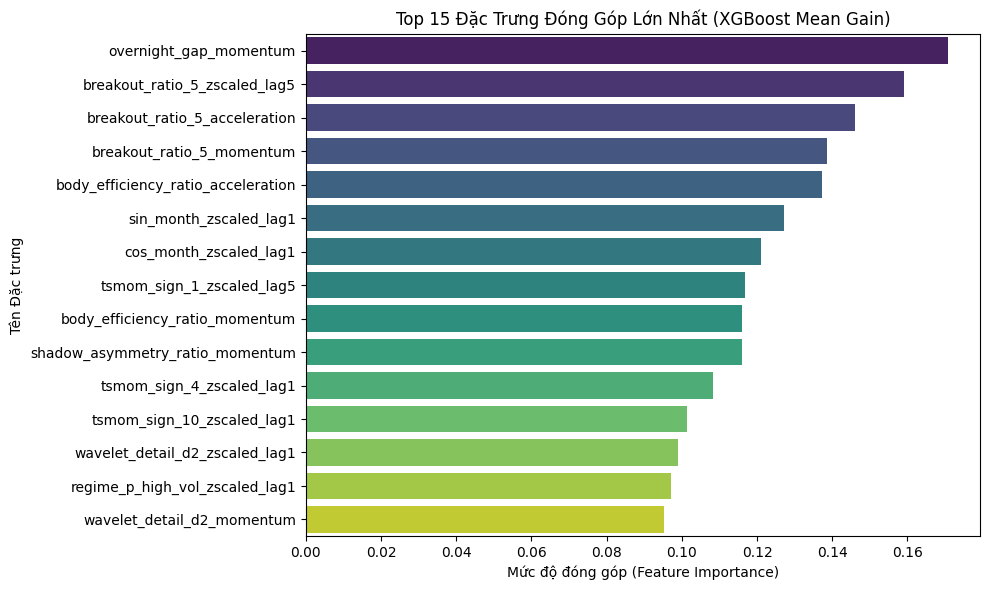

In [ ]:
def analyze_feature_importance(trained_models, pipeline_feature_names_list):
    """
    Trích xuất và trung bình hóa Feature Importance từ các mô hình XGBoost qua các Fold.
    (Lưu ý: pipeline_feature_names_list là danh sách các cột X_test.columns ở mỗi fold)
    """
    print("\n" + "=" * 60)
    print("PHÂN TÍCH TẦM QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE)")
    print("=" * 60)

    importance_records = []

    # Lặp qua từng Fold
    for i, model in enumerate(trained_models):
        # Lấy feature importances (Gain) từ XGBoost
        importances = model.feature_importances_
        # Tên các feature được XGBoost lưu trữ
        feature_names = model.feature_names_in_

        for name, imp in zip(feature_names, importances):
            importance_records.append({
                'Fold': f'Fold_{i+1}',
                'Feature': name,
                'Importance': imp
            })

    df_imp = pd.DataFrame(importance_records)

    # Tính trung bình Importance qua 5 Fold
    df_mean_imp = df_imp.groupby('Feature')['Importance'].mean().sort_values(ascending=False).reset_index()

    # Hiển thị bảng
    print(df_mean_imp.head(15).to_markdown(index=False))

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_mean_imp.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Đặc Trưng Đóng Góp Lớn Nhất (XGBoost Mean Gain)')
    plt.xlabel('Mức độ đóng góp (Feature Importance)')
    plt.ylabel('Tên Đặc trưng')
    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp (vì trained_models đã được lưu ở vòng lặp trước)
# Nếu bạn chưa lưu X_test.columns, XGBoost phiên bản mới đã tự lưu trong model.feature_names_in_
analyze_feature_importance(trained_models, None)

## Visualization


Đang nội suy lợi nhuận để vẽ Equity Curve...


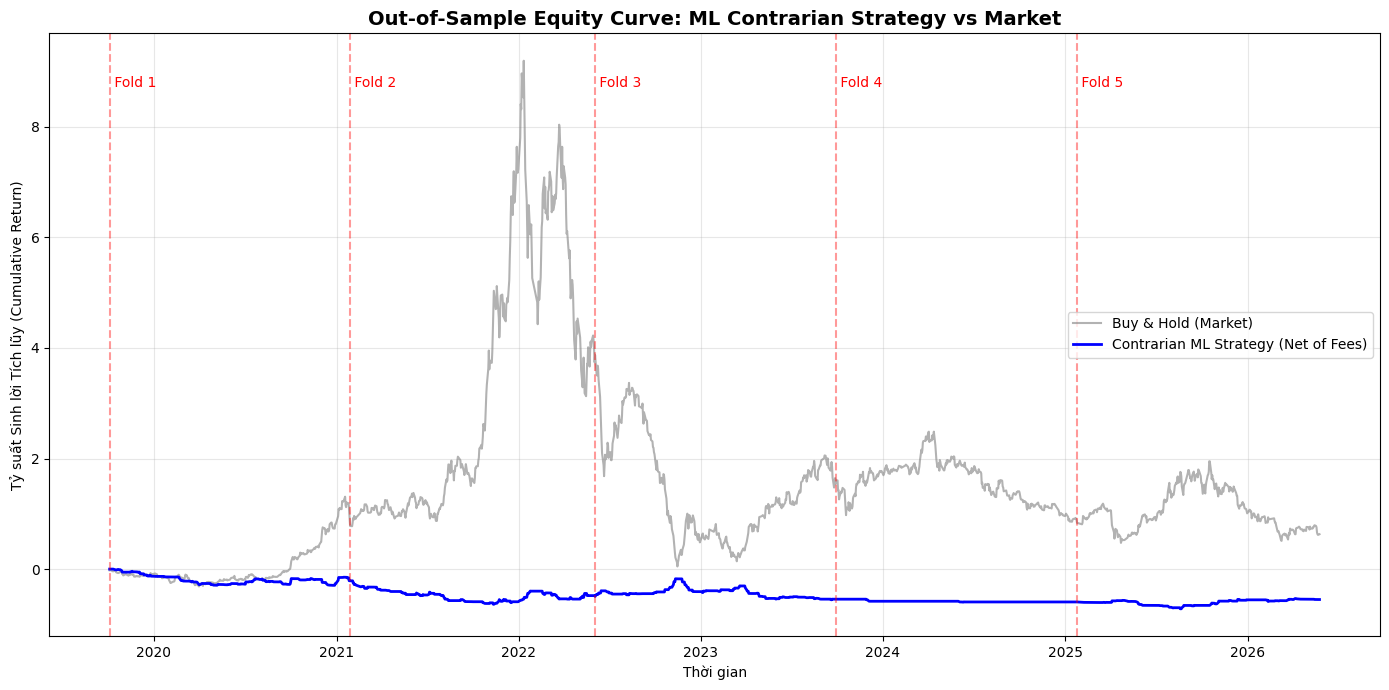

In [ ]:
def plot_equity_curve(oos_predictions, raw_df):
    """
    Vẽ đường cong tích lũy lợi nhuận của chiến lược Contrarian so với Buy & Hold.
    """
    print("\nĐang nội suy lợi nhuận để vẽ Equity Curve...")

    # Kết hợp kết quả dự báo với lợi nhuận thực tế hàng ngày (không phải barrier return)
    # df_final có cột 'log_return' chứa lợi nhuận hàng ngày
    perf_df = oos_predictions.join(raw_df[['log_return']], how='left')

    # Tín hiệu được dịch sang ngày hôm sau để giao dịch (Tránh Leakage)
    perf_df['position'] = perf_df['predicted_target'].shift(1).fillna(0)

    # Tính lợi nhuận chiến lược (Chưa trừ phí chi tiết từng ngày, chỉ ước lượng thô để vẽ trend)
    FEE_PER_TRADE = 0.0020 # 20 bps
    perf_df['trade_flag'] = perf_df['position'].diff().abs() > 0
    perf_df['strat_return'] = (perf_df['position'] * perf_df['log_return']) - (perf_df['trade_flag'] * FEE_PER_TRADE)

    # Tính Equity (Tích lũy)
    perf_df['Cumulative_Market'] = perf_df['log_return'].cumsum()
    perf_df['Cumulative_Strategy'] = perf_df['strat_return'].cumsum()

    # Vẽ biểu đồ
    plt.figure(figsize=(14, 7))
    plt.plot(perf_df.index, np.exp(perf_df['Cumulative_Market']) - 1, label='Buy & Hold (Market)', color='gray', alpha=0.6)
    plt.plot(perf_df.index, np.exp(perf_df['Cumulative_Strategy']) - 1, label='Contrarian ML Strategy (Net of Fees)', color='blue', linewidth=2)

    # Đánh dấu các mốc chia Fold
    fold_starts = perf_df.groupby('fold').apply(lambda x: x.index[0]).values
    for i, start_date in enumerate(fold_starts):
        plt.axvline(x=start_date, color='red', linestyle='--', alpha=0.4)
        plt.text(start_date, plt.ylim()[1]*0.9, f' Fold {i+1}', color='red', fontsize=10)

    plt.title('Out-of-Sample Equity Curve: ML Contrarian Strategy vs Market', fontsize=14, fontweight='bold')
    plt.xlabel('Thời gian')
    plt.ylabel('Tỷ suất Sinh lời Tích lũy (Cumulative Return)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp (raw_df là df_final hoặc bảng giá gốc chứa 'log_return')
plot_equity_curve(full_oos_predictions, df_final)